In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Додаємо кореневу паку проєкту до PATH, щоб імпортувати наші модулі
sys.path.append(os.path.abspath('..'))
from src.processing import extract_time_features

print("Бібліотеки успішно імпортовано!")


Бібліотеки успішно імпортовано!


In [2]:
# Шлях до нашого збереженого файлу (піднімаємося на рівень вище з папки notebooks)
processed_data_path = os.path.join("..", "data", "processed", "alerts_2026_processed.csv")

# Завантажуємо
df = pd.read_csv(processed_data_path)

# Застосовуємо функцію для створення часових ознак
df_features = extract_time_features(df)

# Подивимося на результат
df_features.head()

Генерація часових ознак...


,oblast,raion,hromada,level,started_at,finished_at,source,duration_min,date,month,day_of_week,hour,day_name,is_weekend
0,Сумська область,Шосткинський район,Весь район,raion,2026-01-01 02:22:48+02:00,2026-01-01 04:10:51+02:00,official,108.050000,2026-01-01,1,3,2,Чт,0
1,Сумська область,Конотопський район,Весь район,raion,2026-01-01 02:22:57+02:00,2026-01-01 04:11:00+02:00,official,108.050000,2026-01-01,1,3,2,Чт,0
2,Сумська область,Сумський район,Весь район,raion,2026-01-01 02:35:17+02:00,2026-01-01 04:10:30+02:00,official,95.216667,2026-01-01,1,3,2,Чт,0
3,Чернігівська область,Ніжинський район,Весь район,raion,2026-01-01 02:47:38+02:00,2026-01-01 06:50:35+02:00,official,242.950000,2026-01-01,1,3,2,Чт,0
4,Волинська область,Луцький район,Весь район,raion,2026-01-01 02:50:55+02:00,2026-01-01 06:03:20+02:00,official,192.416667,2026-01-01,1,3,2,Чт,0


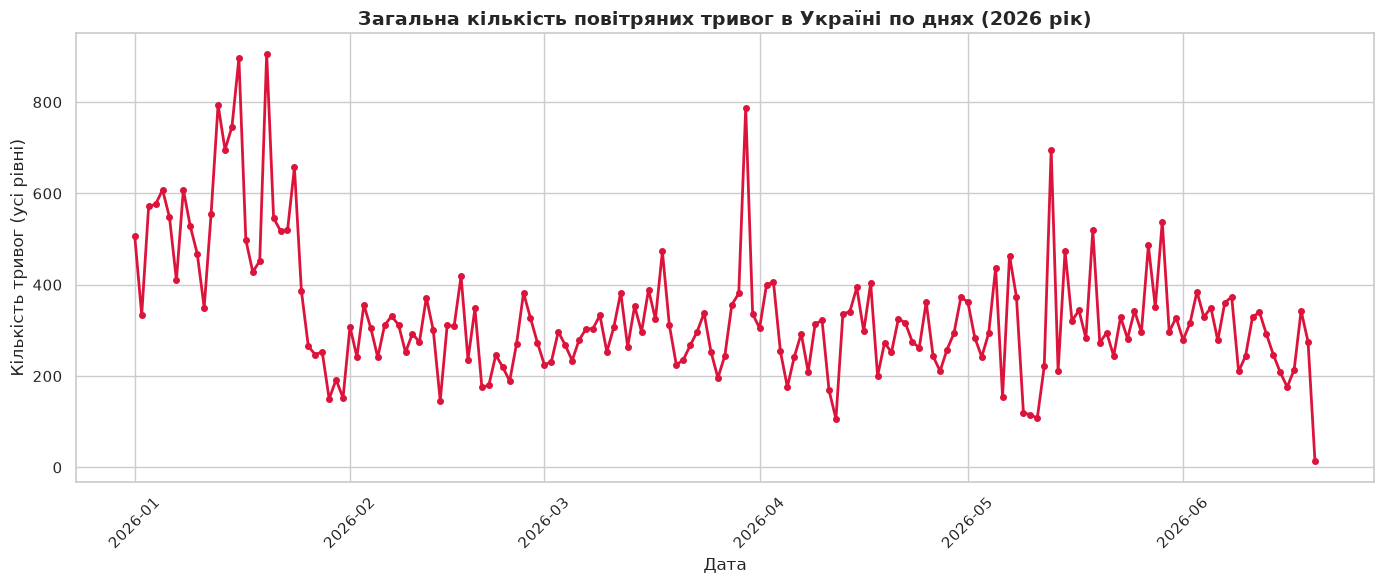

In [ ]:
# Групуємо за датою та рахуємо кількість записів
daily_alerts = df_features.groupby('date').size().reset_index(name='alerts_count')

# Будуємо графік часового ряду
plt.figure(figsize=(14, 6))
plt.plot(daily_alerts['date'], daily_alerts['alerts_count'], color='crimson', linewidth=2, marker='o', markersize=4)

plt.title('Загальна кількість повітряних тривог в Україні по днях (2026 рік)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Кількість тривог (усі рівні)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_134346/3697511275.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='alerts_count', data=hourly_alerts, palette='viridis')


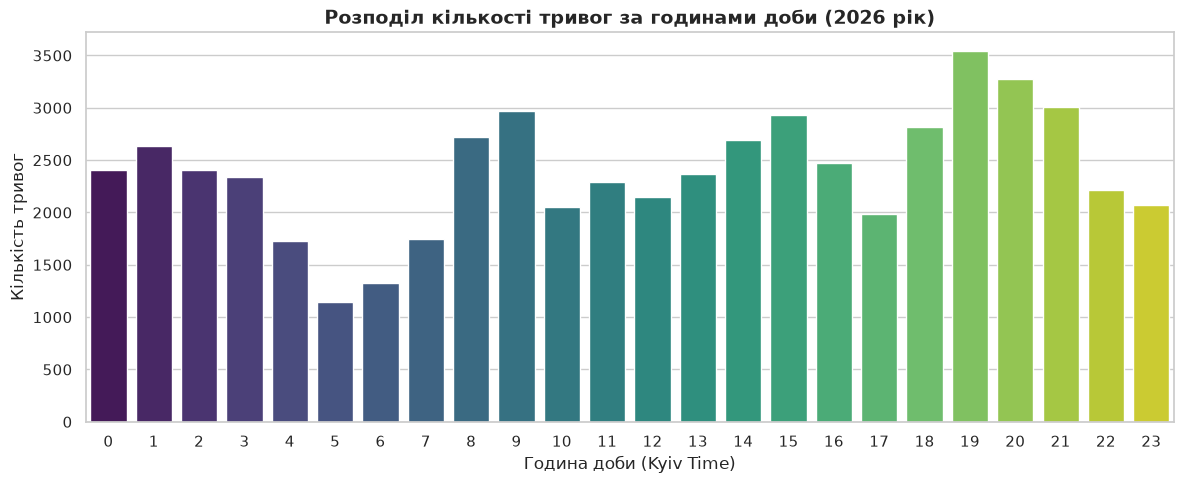

In [4]:
# Розподіл за годинами
hourly_alerts = df_features.groupby('hour').size().reset_index(name='alerts_count')

# Будуємо стовпчикову діаграму
plt.figure(figsize=(12, 5))
sns.barplot(x='hour', y='alerts_count', data=hourly_alerts, palette='viridis')

plt.title('Розподіл кількості тривог за годинами доби (2026 рік)', fontsize=14, fontweight='bold')
plt.xlabel('Година доби (Kyiv Time)', fontsize=12)
plt.ylabel('Кількість тривог', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_134346/3596313048.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_hours', y='oblast', data=top_oblast_duration, palette='flare')


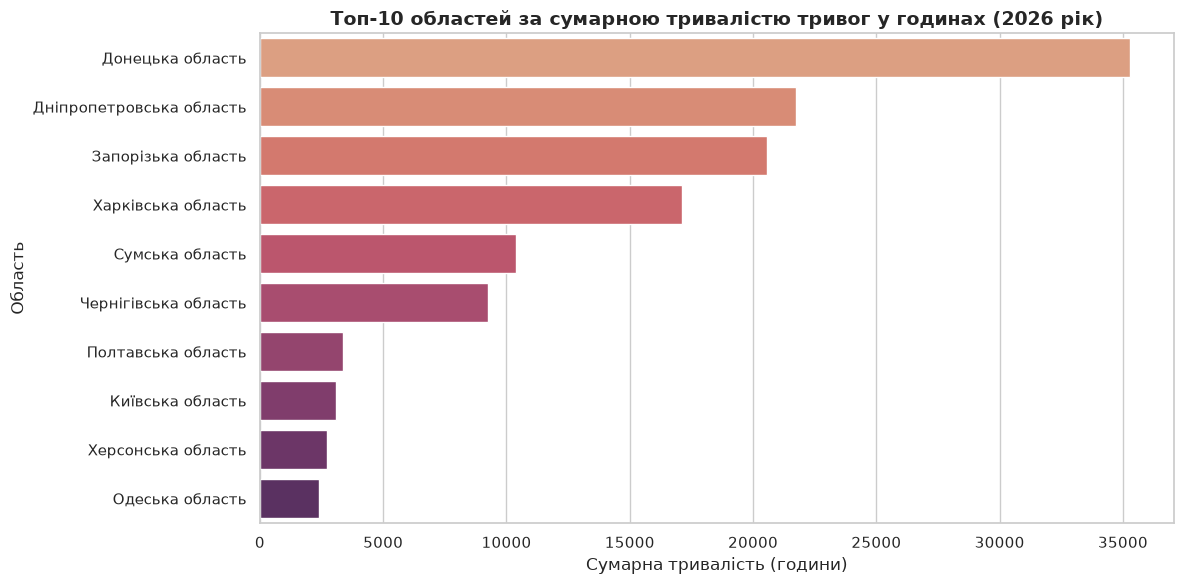

In [5]:
# Групуємо за областями та рахуємо сумарну тривалість у годинах
oblast_duration = df_features.groupby('oblast')['duration_min'].sum().reset_index()
oblast_duration['duration_hours'] = oblast_duration['duration_min'] / 60.0

# Сортуємо за спаданням та беремо Топ-10
top_oblast_duration = oblast_duration.sort_values(by='duration_hours', ascending=False).head(10)

# Візуалізація
plt.figure(figsize=(12, 6))
sns.barplot(x='duration_hours', y='oblast', data=top_oblast_duration, palette='flare')

plt.title('Топ-10 областей за сумарною тривалістю тривог у годинах (2026 рік)', fontsize=14, fontweight='bold')
plt.xlabel('Сумарна тривалість (години)', fontsize=12)
plt.ylabel('Область', fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipykernel_134346/1355643212.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_name', y='daily_count', data=weekday_alerts, palette='Set2')


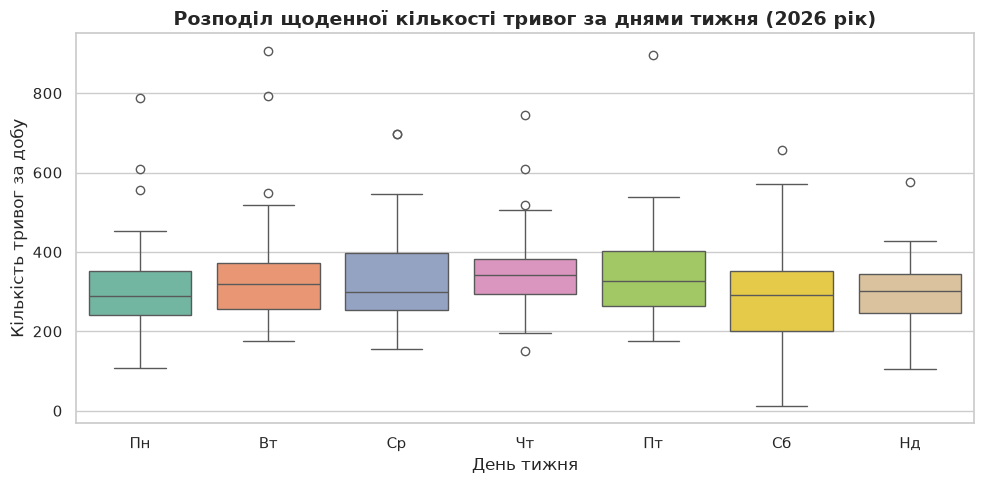

In [6]:
# Групуємо по днях тижня для аналізу стабільності тренду
weekday_alerts = df_features.groupby(['date', 'day_name', 'day_of_week']).size().reset_index(name='daily_count')
weekday_alerts = weekday_alerts.sort_values('day_of_week')

plt.figure(figsize=(10, 5))
sns.boxplot(x='day_name', y='daily_count', data=weekday_alerts, palette='Set2')

plt.title('Розподіл щоденної кількості тривог за днями тижня (2026 рік)', fontsize=14, fontweight='bold')
plt.xlabel('День тижня', fontsize=12)
plt.ylabel('Кількість тривог за добу', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
import json

with open("../data/raw/regiony.geojson", "r", encoding="utf-8") as f:
    geo_data = json.load(f)

# Дивимося на ключі першого регіону у файлі
print(geo_data['features'][0]['properties'])

{'fid': 0, 'region': 'Автономна Республіка Крим'}


In [9]:
import json
import pandas as pd

# 1. Читаємо назви з GeoJSON
with open("../data/raw/regiony.geojson", "r", encoding="utf-8") as f:
    geojson_data = json.load(f)
geojson_names = [f['properties']['region'] for f in geojson_data['features'] if 'region' in f['properties']]

# 2. Читаємо назви з нашого вже обробленого CSV (піднімемося на рівень вище з папки notebooks)
df_csv = pd.read_csv("../data/processed/alerts_2026_processed.csv")
csv_names = df_csv['oblast'].unique().tolist()

print("--- НАЗВИ В GEOJSON ---")
print(geojson_names[:5])  # покажемо перші 5 для прикладу
print("\n--- НАЗВИ В CSV ---")
print(csv_names[:5])

--- НАЗВИ В GEOJSON ---
['Автономна Республіка Крим', 'Вінницька область', 'Волинська область', 'Дніпропетровська область', 'Донецька область']

--- НАЗВИ В CSV ---
['Сумська область', 'Чернігівська область', 'Волинська область', 'Одеська область', 'Харківська область']
